# Fed-Vis: Federated Training (v7 — GroupNorm + FedProx)
2-node federation: KNH (Brain) + AKU (Prostate)
**GroupNorm** (stable with small batches) + **FedProx** + Cosine LR w/ Warmup + Mixed Precision + Early Stopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, torch, numpy as np, nibabel as nib, random, math
import matplotlib.pyplot as plt
from glob import glob
from scipy.ndimage import zoom
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

DRIVE = '/content/drive/MyDrive/Capstone'
print("Files:", os.listdir(DRIVE))

Mounted at /content/drive
Files: ['MICCAI_FeTS2022_TrainingData.zip', 'Processed_data_nii.zip', 'Task06_Lung.tar', 'trained_models', 'Task02_Heart.tar', 'fed_checkpoints']


In [ ]:
if os.path.exists('/content/FedFMS'):
    shutil.rmtree('/content/FedFMS')
!git clone https://github.com/JoakBouy/Fed-Vis_Mission-Capstone.git /content/FedFMS
sys.path.insert(0, '/content/FedFMS/src')
!pip install -q nibabel flwr hydra-core omegaconf SimpleITK

# Patch blocks.py: replace BatchNorm with GroupNorm (stable with batch_size=2)
blocks_path = '/content/FedFMS/src/fedvis/models/blocks.py'
with open(blocks_path, 'r') as f:
    code = f.read()
code = code.replace('nn.BatchNorm3d(out_channels)', 'nn.GroupNorm(min(8, out_channels), out_channels)')
code = code.replace('nn.BatchNorm3d(inter_channels)', 'nn.GroupNorm(min(8, inter_channels), inter_channels)')
code = code.replace('self.bn1 =', 'self.norm1 =').replace('self.bn2 =', 'self.norm2 =')
code = code.replace('self.bn1(', 'self.norm1(').replace('self.bn2(', 'self.norm2(')
with open(blocks_path, 'w') as f:
    f.write(code)
print("Patched blocks.py → GroupNorm")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU")

Cloning into '/content/FedFMS'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 110 (delta 21), reused 95 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 1.43 MiB | 17.40 MiB/s, done.
Resolving deltas: 100% (21/21), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.6/782.6 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 5.0 MB/s eta 0:00:00
ERROR: pip's de

## 1. Extract Data


In [ ]:
D = '/content/data'
os.makedirs(D, exist_ok=True)

fets_dir = f'{D}/FeTS2022'
if not os.path.exists(fets_dir):
    print("Extracting FeTS...")
    !unzip -q "{DRIVE}/MICCAI_FeTS2022_TrainingData.zip" -d "{fets_dir}"
    print("Done.")

prost_dir = f'{D}/Prostate'
if not os.path.exists(prost_dir):
    print("Extracting Prostate...")
    !unzip -q "{DRIVE}/Processed_data_nii.zip" -d "{prost_dir}"
    print("Done.")

!find /content/data -name '._*' -delete 2>/dev/null

for n, d in [('FeTS', fets_dir), ('Prostate', prost_dir)]:
    count = len(glob(os.path.join(d, '**/*.nii.gz'), recursive=True))
    print(f"{n}: {count} files")

Extracting FeTS...
Done.
Extracting Prostate...
Done.
FeTS: 6255 files
Prostate: 232 files


## 2. Dataset


In [ ]:
TARGET = (64, 128, 128)

def crop_or_pad(vol, target):
    out = np.zeros(target, dtype=vol.dtype)
    slices = tuple(slice(0, min(v, t)) for v, t in zip(vol.shape, target))
    out[slices] = vol[slices]
    return out

class MedDataset(Dataset):
    def __init__(self, imgs, masks, aug=False, norm='zscore'):
        assert len(imgs) == len(masks)
        self.imgs, self.masks, self.aug, self.norm = imgs, masks, aug, norm
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        vol = nib.load(self.imgs[i]).get_fdata().astype(np.float32)
        msk = nib.load(self.masks[i]).get_fdata().astype(np.float32)
        if vol.ndim == 4: vol = vol[..., 0]
        if msk.ndim == 4: msk = msk[..., 0]
        if self.norm == 'zscore':
            fg = vol > 0
            if fg.sum() > 0:
                vol[fg] = (vol[fg] - vol[fg].mean()) / (vol[fg].std() + 1e-8)
            vol[~fg] = 0
        else:
            lo, hi = np.percentile(vol, [0.5, 99.5])
            if hi > lo:
                vol = np.clip((vol - lo) / (hi - lo), 0, 1)
        msk = (msk > 0).astype(np.float32)
        if vol.shape != TARGET:
            f = [t / s for t, s in zip(TARGET, vol.shape)]
            vol = zoom(vol, f, order=1)
            msk = zoom(msk, f, order=0)
        vol = crop_or_pad(vol, TARGET)
        msk = crop_or_pad(msk, TARGET)
        msk = (msk > 0.5).astype(np.float32)
        if self.aug:
            # Spatial: flips + rotation
            for ax in range(3):
                if random.random() > 0.5:
                    vol = np.flip(vol, ax).copy()
                    msk = np.flip(msk, ax).copy()
            k = random.randint(0, 3)
            if k:
                vol = np.rot90(vol, k, (1, 2)).copy()
                msk = np.rot90(msk, k, (1, 2)).copy()
            # Intensity: noise + brightness + contrast
            if random.random() > 0.5:
                vol = vol + np.random.normal(0, 0.03, vol.shape).astype(np.float32)
            if random.random() > 0.5:
                vol = vol * np.random.uniform(0.9, 1.1)
            if random.random() > 0.5:
                mean = vol.mean()
                vol = (vol - mean) * np.random.uniform(0.85, 1.15) + mean
        return (torch.from_numpy(vol.copy()).unsqueeze(0).float(),
                torch.from_numpy(msk.copy()).unsqueeze(0).float())

print("Dataset class ready.")

Dataset class ready.


## 3. Find Pairs


In [ ]:
def find_brats(d):
    imgs, masks = [], []
    for seg in sorted(glob(os.path.join(d, '**/*seg*.nii.gz'), recursive=True)):
        bn = os.path.basename(seg)
        if bn.startswith('._'):
            continue
        cands = [c for c in glob(os.path.join(os.path.dirname(seg), '*.nii.gz'))
                 if 'seg' not in c.lower() and not os.path.basename(c).startswith('._')]
        if cands:
            imgs.append(sorted(cands)[0])
            masks.append(seg)
    return imgs, masks

def find_prostate(d):
    i, m = find_brats(d)
    if i:
        return i, m
    imgs, masks = [], []
    for f in sorted(glob(os.path.join(d, '**/*.nii.gz'), recursive=True)):
        if 'seg' in f.lower() or os.path.basename(f).startswith('._'):
            continue
        s = f.replace('.nii.gz', '_segmentation.nii.gz')
        if os.path.exists(s):
            imgs.append(f)
            masks.append(s)
    return imgs, masks

fets_i, fets_m = find_brats(fets_dir)
prost_i, prost_m = find_prostate(prost_dir)
print(f"FeTS: {len(fets_i)} pairs | Prostate: {len(prost_i)} pairs")

FeTS: 1251 pairs | Prostate: 86 pairs


## 4. Verify + Preview


FeTS: shape=(1, 64, 128, 128) range=[-2.65,4.88] fg=6622 (0.63%)
Prostate: shape=(1, 64, 128, 128) range=[-0.85,33.93] fg=23634 (2.25%)


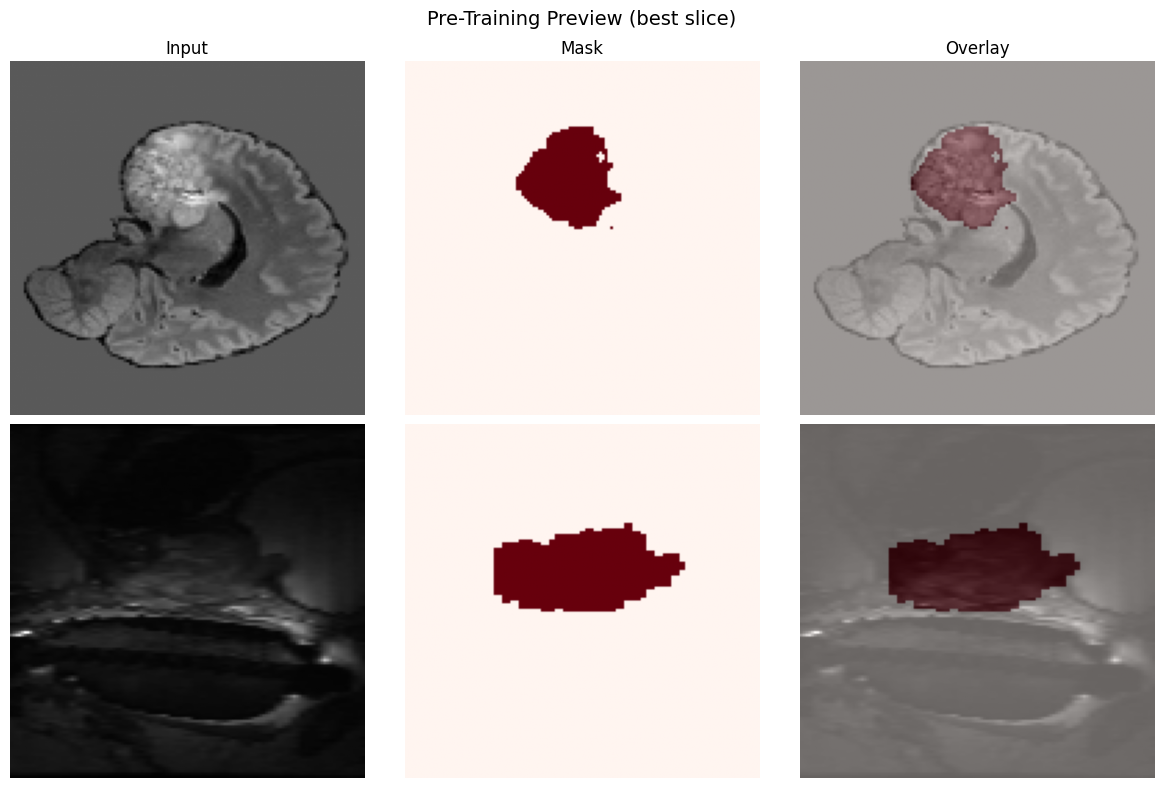

Ready for training.


In [ ]:
for name, imgs, masks in [
    ('FeTS', fets_i, fets_m),
    ('Prostate', prost_i, prost_m),
]:
    if not imgs:
        print(f"{name}: no data")
        continue
    ds = MedDataset(imgs[:1], masks[:1])
    v, m = ds[0]
    fg = m.sum().item()
    print(f"{name}: shape={tuple(v.shape)} range=[{v.min():.2f},{v.max():.2f}] "
          f"fg={fg:.0f} ({100*fg/m.numel():.2f}%)")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, (name, imgs, masks) in enumerate([
    ('FeTS (Brain)', fets_i, fets_m),
    ('Prostate', prost_i, prost_m),
]):
    if not imgs:
        continue
    ds = MedDataset(imgs[:1], masks[:1])
    v, m = ds[0]
    fg_slices = m[0].sum(dim=(1, 2))
    mid = fg_slices.argmax().item() if fg_slices.max() > 0 else v.shape[1] // 2
    vn = v[0, mid].numpy()
    mn = m[0, mid].numpy()
    axes[row, 0].imshow(vn, cmap='gray')
    axes[row, 1].imshow(mn, cmap='Reds', vmin=0, vmax=1)
    axes[row, 2].imshow(vn, cmap='gray')
    axes[row, 2].imshow(mn, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
    axes[row, 0].set_ylabel(name, fontsize=12, fontweight='bold')
    if row == 0:
        for c, t in enumerate(['Input', 'Mask', 'Overlay']):
            axes[0, c].set_title(t, fontsize=12)
for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Pre-Training Preview (best slice)', fontsize=14)
plt.tight_layout()
plt.show()
print("Ready for training.")

## 5. Training Functions
**Key changes from v6:**
- **GroupNorm** replaces BatchNorm → stable with batch_size=2 and small datasets (Heart)
- **No FedBN needed** → GroupNorm has no running statistics, so all params aggregate normally via FedAvg
- **FedProx inside autocast** → proximal term now properly gradient-scaled
- **Equal loss weighting** (50/50 Dice + BCE) per proposal
- **Grad clip relaxed** to 5.0 (was 1.0, which choked learning)
- **Eval includes** sensitivity + precision alongside Dice

In [ ]:
from fedvis.models.attention_unet import AttentionUNet3D
from fedvis.models.losses import CombinedLoss, dice_coefficient

def get_params(m):
    return [v.cpu().detach().numpy() for v in m.state_dict().values()]

def set_params(m, p):
    sd = OrderedDict()
    for k, v in zip(m.state_dict().keys(), p):
        sd[k] = torch.tensor(v)
    m.load_state_dict(sd, strict=True)

MU = 0.01  # FedProx proximal strength

def train_ep_prox(m, ld, dev, global_model, lr):
    """Train one epoch with FedProx + mixed precision (all inside autocast)."""
    m.train()
    criterion = CombinedLoss(1.0, 1.0)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    scaler = torch.amp.GradScaler('cuda')
    tl = 0
    for v, mk in ld:
        v, mk = v.to(dev), mk.to(dev)
        opt.zero_grad()
        with torch.amp.autocast('cuda'):
            pred = m(v)
            loss = criterion(pred, mk)
            # FedProx proximal term — inside autocast for correct scaling
            prox = torch.tensor(0.0, device=dev)
            for local_p, global_p in zip(m.parameters(), global_model.parameters()):
                prox = prox + ((local_p - global_p.detach()) ** 2).sum()
            loss = loss + (MU / 2.0) * prox
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(m.parameters(), 5.0)
        scaler.step(opt)
        scaler.update()
        tl += loss.item()
    return tl / len(ld)

def eval_m(m, ld, dev):
    """Evaluate: returns dict with dice, sensitivity, precision."""
    m.eval()
    dices, sens, precs = [], [], []
    with torch.no_grad():
        for v, mk in ld:
            v, mk = v.to(dev), mk.to(dev)
            with torch.amp.autocast('cuda'):
                pred = torch.sigmoid(m(v))
            pred_bin = (pred > 0.5).float()
            dices.append(dice_coefficient(pred, mk).item())
            tp = (pred_bin * mk).sum().item()
            fn = (mk * (1 - pred_bin)).sum().item()
            fp = (pred_bin * (1 - mk)).sum().item()
            sens.append(tp / (tp + fn + 1e-8))
            precs.append(tp / (tp + fp + 1e-8))
    return {'dice': np.mean(dices), 'sensitivity': np.mean(sens), 'precision': np.mean(precs)}

def fedavg(params_list, sizes):
    """Standard FedAvg — GroupNorm has no running stats, so all params aggregate."""
    total = sum(sizes)
    w = [s / total for s in sizes]
    return [sum(wt * p[i] for wt, p in zip(w, params_list))
            for i in range(len(params_list[0]))]

_tmp = AttentionUNet3D(1, 1, 32)
print(f"GroupNorm model: {sum(p.numel() for p in _tmp.parameters()):,} params")
print(f"All {len(list(_tmp.state_dict().keys()))} params will be aggregated (no BN exclusions)")
del _tmp
print(f"FedProx (mu={MU}) + GroupNorm + AMP ready.")

GroupNorm model: 22,710,037 params
All 96 params will be aggregated (no BN exclusions)
FedProx (mu=0.01) + GroupNorm + AMP ready.


## 6. Setup Nodes


In [ ]:
def mk_ld(imgs, masks, mx, norm='zscore'):
    n = min(len(imgs), mx)
    ii = list(range(len(imgs)))
    random.seed(42)
    random.shuffle(ii)
    ii = ii[:n]
    s = int(0.85 * n)
    tds = MedDataset([imgs[i] for i in ii[:s]], [masks[i] for i in ii[:s]], aug=True, norm=norm)
    vds = MedDataset([imgs[i] for i in ii[s:]], [masks[i] for i in ii[s:]], norm=norm)
    return (DataLoader(tds, 2, shuffle=True, num_workers=2, pin_memory=True),
            DataLoader(vds, 2, num_workers=2, pin_memory=True))

nodes = {}
if fets_i:
    nodes['KNH-Brain'] = mk_ld(fets_i, fets_m, 200)
if prost_i:
    nodes['AKU-Prostate'] = mk_ld(prost_i, prost_m, 120)

for n, (t, v) in nodes.items():
    print(f"{n}: {len(t.dataset)} train, {len(v.dataset)} val")

KNH-Brain: 170 train, 30 val
AKU-Prostate: 73 train, 13 val


## 7. Federated Training (FedProx + GroupNorm)
- **2 nodes**: KNH-Brain (up to 200 samples) + AKU-Prostate (up to 120 samples)
- **5 local epochs** per round — both datasets large enough to benefit
- **Warmup** for first 3 rounds → cosine decay
- **Pure FedAvg** — GroupNorm has no running stats to exclude
- **Early stopping** patience=10

In [ ]:
import math, time, torch, os, numpy as np

ROUNDS = 45
LOC_EP = 5
BASE_LR = 3e-4
WARMUP = 3

gm = AttentionUNet3D(1, 1, 32).to(device)
gp = get_params(gm)
FED = '/content/outputs/fed'
os.makedirs(FED, exist_ok=True)

# Track per-node dice + global metrics
fhist = {n: [] for n in nodes}
fhist['Global'] = []
fhist_sens = []
fhist_prec = []
bg = 0.0
patience, wait = 10, 0
start_round = 0

# ── RESUME FROM SPECIFIC CHECKPOINT ──
CKPT_DIR = f'{DRIVE}/trained_models'
# Fallback directory if Drive is read-only
LOCAL_CKPT_DIR = '/content/checkpoints'
os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)

# Updated to user specified checkpoint
latest_ckpt = f'{CKPT_DIR}/checkpoint_r35.pth'

if os.path.exists(latest_ckpt):
    ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
    gm.load_state_dict(ckpt['model'])
    gp = get_params(gm)
    start_round = ckpt['round'] + 1
    bg = ckpt.get('dice', 0.0)
    print(f'✅ Resumed from round {start_round}, best dice={bg:.4f}')
    del ckpt
else:
    print(f"Checkpoint {latest_ckpt} not found, check path or starting fresh.")

t0 = time.time()

for rnd in range(start_round, ROUNDS):
    if rnd < WARMUP:
        lr = BASE_LR * (rnd + 1) / WARMUP
    else:
        lr = BASE_LR * 0.5 * (1 + math.cos(math.pi * (rnd - WARMUP) / (ROUNDS - WARMUP)))

    ap, az = [], []
    for name, (tl, vl) in nodes.items():
        lm = AttentionUNet3D(1, 1, 32).to(device)
        set_params(lm, gp)
        gm_copy = AttentionUNet3D(1, 1, 32).to(device)
        set_params(gm_copy, gp)
        gm_copy.eval()
        for p in gm_copy.parameters(): p.requires_grad = False

        for _ in range(LOC_EP):
            train_ep_prox(lm, tl, device, gm_copy, lr)

        ap.append(get_params(lm))
        az.append(len(tl.dataset))
        metrics = eval_m(lm, vl, device)
        fhist[name].append(metrics['dice'])
        # Partial history recovery logic could go here if fhist was persistent
        del lm, gm_copy
        torch.cuda.empty_cache()

    gp = fedavg(ap, az)
    set_params(gm, gp)

    global_metrics = []
    for _, (_, vl) in nodes.items():
        global_metrics.append(eval_m(gm, vl, device))
    gd = np.mean([m['dice'] for m in global_metrics])
    fhist['Global'].append(gd)
    fhist_sens.append(np.mean([m['sensitivity'] for m in global_metrics]))
    fhist_prec.append(np.mean([m['precision'] for m in global_metrics]))

    if gd > bg:
        bg = gd
        wait = 0
        torch.save({'round': rnd, 'model': gm.state_dict(), 'dice': bg}, f'{FED}/global_best.pth')
    else:
        wait += 1

    if (rnd + 1) % 5 == 0:
        save_path = f'{CKPT_DIR}/checkpoint_r{rnd+1}.pth'
        try:
            torch.save({'round': rnd, 'model': gm.state_dict(), 'dice': bg}, save_path)
        except RuntimeError as e:
            print(f"⚠️ Drive write failed, saving locally: {e}")
            save_path = f'{LOCAL_CKPT_DIR}/checkpoint_r{rnd+1}.pth'
            torch.save({'round': rnd, 'model': gm.state_dict(), 'dice': bg}, save_path)

    ns = ' | '.join(f"{n.split('-')[1]}={fhist[n][-1]:.3f}" for n in nodes)
    print(f"R{rnd+1:2d}/{ROUNDS} lr={lr:.5f} | Global: dice={gd:.3f} | {ns} | wait={wait}/{patience}")

    if wait >= patience: break

✅ Resumed from round 35, best dice=0.6891
R36/45 lr=0.00004 | Global: dice=0.698 | Brain=0.907 | Prostate=0.638 | wait=0/10
R37/45 lr=0.00003 | Global: dice=0.722 | Brain=0.908 | Prostate=0.652 | wait=0/10
R38/45 lr=0.00003 | Global: dice=0.679 | Brain=0.910 | Prostate=0.629 | wait=1/10
R39/45 lr=0.00002 | Global: dice=0.696 | Brain=0.910 | Prostate=0.640 | wait=2/10
R40/45 lr=0.00001 | Global: dice=0.714 | Brain=0.910 | Prostate=0.645 | wait=3/10
R41/45 lr=0.00001 | Global: dice=0.724 | Brain=0.909 | Prostate=0.642 | wait=0/10
R42/45 lr=0.00001 | Global: dice=0.722 | Brain=0.911 | Prostate=0.645 | wait=1/10
R43/45 lr=0.00000 | Global: dice=0.720 | Brain=0.910 | Prostate=0.639 | wait=2/10
R44/45 lr=0.00000 | Global: dice=0.712 | Brain=0.910 | Prostate=0.624 | wait=3/10
R45/45 lr=0.00000 | Global: dice=0.710 | Brain=0.910 | Prostate=0.598 | wait=4/10


## 8. Results


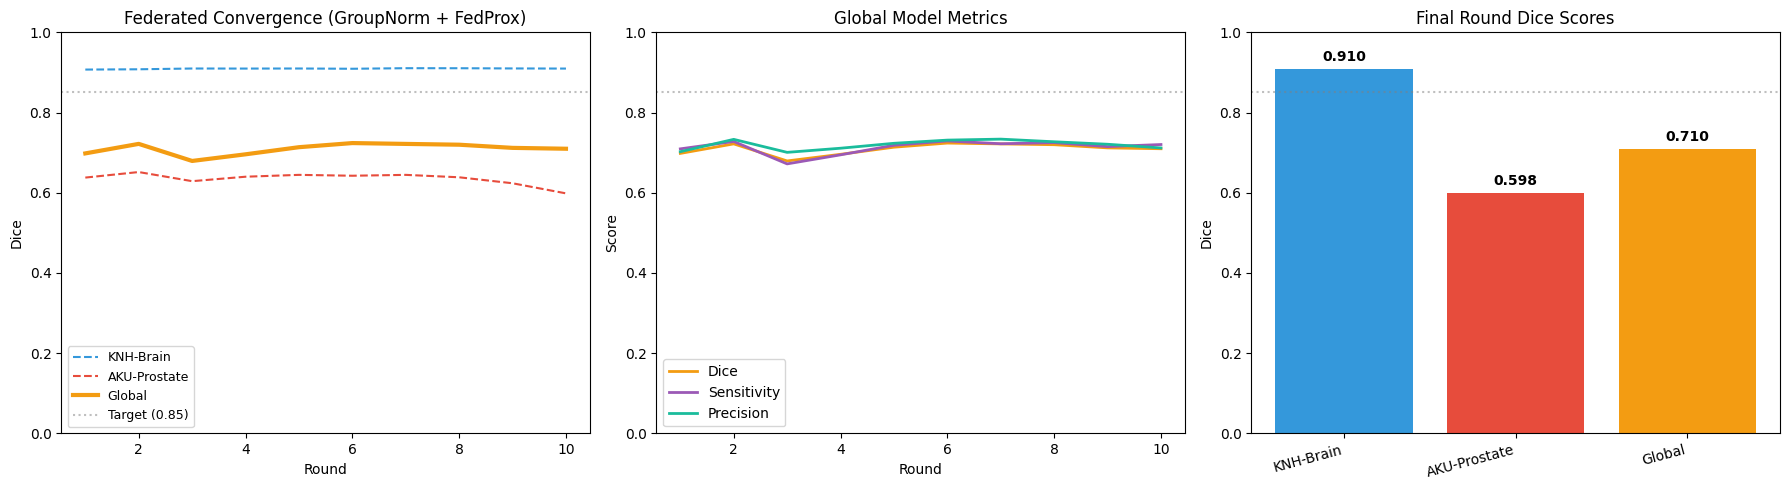

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clr = {'KNH-Brain': '#3498db', 'AKU-Prostate': '#e74c3c', 'Global': '#f39c12'}

# Plot 1: Dice convergence
ax = axes[0]
for n, d in fhist.items():
    style = '-' if n == 'Global' else '--'
    lw = 3 if n == 'Global' else 1.5
    ax.plot(range(1, len(d)+1), d, style, label=n, linewidth=lw, color=clr.get(n, 'gray'))
ax.axhline(.85, color='gray', ls=':', alpha=.5, label='Target (0.85)')
ax.set_ylim(0, 1)
ax.set_xlabel('Round')
ax.set_ylabel('Dice')
ax.legend(fontsize=9)
ax.set_title('Federated Convergence (GroupNorm + FedProx)')

# Plot 2: Global metrics (dice + sensitivity + precision)
ax = axes[1]
rounds_x = range(1, len(fhist['Global'])+1)
ax.plot(rounds_x, fhist['Global'], '-', label='Dice', color='#f39c12', linewidth=2)
ax.plot(rounds_x, fhist_sens, '-', label='Sensitivity', color='#9b59b6', linewidth=2)
ax.plot(rounds_x, fhist_prec, '-', label='Precision', color='#1abc9c', linewidth=2)
ax.axhline(.85, color='gray', ls=':', alpha=.5)
ax.set_ylim(0, 1)
ax.set_xlabel('Round')
ax.set_ylabel('Score')
ax.legend()
ax.set_title('Global Model Metrics')

# Plot 3: Final bar chart
ax = axes[2]
final = {n: d[-1] for n, d in fhist.items()}
bars = ax.bar(final.keys(), final.values(),
              color=[clr.get(n, 'gray') for n in final])
ax.set_ylim(0, 1)
ax.set_ylabel('Dice')
ax.set_title('Final Round Dice Scores')
for bar, v in zip(bars, final.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(.85, color='gray', ls=':', alpha=.5)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

## 9. Save to Drive


In [ ]:
sd = f'{DRIVE}/trained_models'
os.makedirs(sd, exist_ok=True)
shutil.copy2(f'{FED}/global_best.pth', f'{sd}/federated_global_best_v7.pth')
sz = os.path.getsize(f'{sd}/federated_global_best_v7.pth') / 1e6
print(f"Saved to Drive ({sz:.0f} MB)")
print(f"\nBest Global Dice: {bg:.4f}")
print(f"Algorithm: FedProx (mu={MU}) + GroupNorm + FedAvg")
print(f"Nodes: KNH-Brain + AKU-Prostate")
print(f"Rounds: {ROUNDS}, Local epochs: {LOC_EP}")
print(f"LR: warmup({WARMUP}) + cosine from {BASE_LR}")
print(f"Loss: 50/50 Dice + BCE | Grad clip: 5.0")

Saved to Drive (91 MB)

Best Global Dice: 0.7238
Algorithm: FedProx (mu=0.01) + GroupNorm + FedAvg
Nodes: KNH-Brain + AKU-Prostate
Rounds: 45, Local epochs: 5
LR: warmup(3) + cosine from 0.0003
Loss: 50/50 Dice + BCE | Grad clip: 5.0
